# Análisis Exploratorio de Datos — Astronautas y Misiones Espaciales

Este notebook aplica un Análisis Exploratorio de Datos (EDA) completo sobre un dataset público con información de todos los astronautas que participaron en misiones espaciales antes de enero de 2020 (1.277 misiones registradas, correspondientes a 934 astronautas de distintos países y programas espaciales).

**Objetivo del análisis:** identificar patrones históricos, demográficos y estadísticamente significativos en las misiones espaciales — evolución de la duración de las misiones, participación femenina a lo largo del tiempo, diferencias entre países, y relación entre variables como edad, tipo de misión y perfil profesional.

**Fuente de los datos:** [TidyTuesday](https://github.com/rfordatascience/tidytuesday) (proyecto de datasets públicos para práctica de análisis de datos), recopilado originalmente por Mariya Stavnichuk y Tatsuya Corlett a partir de información pública de NASA, Roscosmos y otras fuentes.

> 📚 A lo largo del notebook se indica, para cada hallazgo, si se confirma con una prueba estadística formal (por ejemplo, test de chi-cuadrado) o si es una hipótesis fundamentada en la evidencia disponible pero no testeada formalmente.

**Metodología:** se sigue la estructura de 3 fases utilizada en trabajos anteriores — comprensión general y estructural del dataset, análisis univariado de cada variable, y finalmente relaciones entre variables con verificación estadística cuando corresponde.

In [1]:
# Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# URL pública del dataset (TidyTuesday, proyecto de datasets para práctica)
url_astronautas = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-07-14/astronauts.csv'

# Cargamos el dataset en un DataFrame
df_astronautas = pd.read_csv(url_astronautas)

# Verificación rápida de la carga
print(f"Filas: {df_astronautas.shape[0]}, Columnas: {df_astronautas.shape[1]}")
df_astronautas.head()

Filas: 1277, Columnas: 24


,id,number,nationwide_number,name,original_name,sex,year_of_birth,nationality,military_civilian,selection,...,year_of_mission,mission_title,ascend_shuttle,in_orbit,descend_shuttle,hours_mission,total_hrs_sum,field21,eva_hrs_mission,total_eva_hrs
0,1,1,1,"Gagarin, Yuri",ГАГАРИН Юрий Алексеевич,male,1934,U.S.S.R/Russia,military,TsPK-1,...,1961,Vostok 1,Vostok 1,Vostok 2,Vostok 3,1.77,1.77,0,0.0,0.0
1,2,2,2,"Titov, Gherman",ТИТОВ Герман Степанович,male,1935,U.S.S.R/Russia,military,TsPK-1,...,1961,Vostok 2,Vostok 2,Vostok 2,Vostok 2,25.00,25.30,0,0.0,0.0
2,3,3,1,"Glenn, John H., Jr.","Glenn, John H., Jr.",male,1921,U.S.,military,NASA Astronaut Group 1,...,1962,MA-6,MA-6,MA-6,MA-6,5.00,218.00,0,0.0,0.0
3,4,3,1,"Glenn, John H., Jr.","Glenn, John H., Jr.",male,1921,U.S.,military,NASA Astronaut Group 2,...,1998,STS-95,STS-95,STS-95,STS-95,213.00,218.00,0,0.0,0.0
4,5,4,2,"Carpenter, M. Scott","Carpenter, M. Scott",male,1925,U.S.,military,NASA- 1,...,1962,Mercury-Atlas 7,Mercury-Atlas 7,Mercury-Atlas 7,Mercury-Atlas 7,5.00,5.00,0,0.0,0.0


In [2]:
# Fase 1 — Comprensión general y estructural

# Tipos de datos y cantidad de valores no nulos por columna
df_astronautas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        1277 non-null   int64  
 1   number                    1277 non-null   int64  
 2   nationwide_number         1277 non-null   int64  
 3   name                      1277 non-null   object 
 4   original_name             1272 non-null   object 
 5   sex                       1277 non-null   object 
 6   year_of_birth             1277 non-null   int64  
 7   nationality               1277 non-null   object 
 8   military_civilian         1277 non-null   object 
 9   selection                 1272 non-null   object 
 10  year_of_selection         1277 non-null   int64  
 11  mission_number            1277 non-null   int64  
 12  total_number_of_missions  1277 non-null   int64  
 13  occupation                1277 non-null   object 
 14  year_of_

In [3]:
# Cantidad de valores nulos por columna, ordenados de mayor a menor
df_astronautas.isnull().sum().sort_values(ascending=False)

,0
original_name,5
selection,5
mission_title,1
descend_shuttle,1
ascend_shuttle,1
id,0
nationwide_number,0
number,0
nationality,0
year_of_birth,0


In [4]:
# Verificamos si hay filas completamente duplicadas
print(f"Filas duplicadas: {df_astronautas.duplicated().sum()}")

Filas duplicadas: 0


In [5]:
# Verificamos qué valores toma la columna 'field21' antes de decidir si la descartamos
df_astronautas['field21'].value_counts()

,count
field21,
0,901
1,136
2,115
3,92
4,15
5,9
6,7
7,2


In [6]:
# Inspeccionamos las filas con nulos en 'selection' para buscar un patrón
df_astronautas[df_astronautas['selection'].isnull()][['name', 'nationality', 'selection', 'original_name']]

,name,nationality,selection,original_name
1066,"Olsen, Gregory Hammond",U.S.,NaN,"Olsen, Gregory Hammond"
1083,"Ansari, Anousheh",U.S.,NaN,انوشه انصاری
1095,"Simonyi, Charles (Karoly)",U.S.,NaN,"Simonyi, Charles (Karoly)"
1096,"Simonyi, Charles (Karoly)",U.S.,NaN,"Simonyi, Charles (Karoly)"
1155,"Garriott, Richard Allen",U.K./U.S.,NaN,"Garriott, Richard Allen"


In [7]:
# Confirmamos la hipótesis: ¿la columna 'occupation' identifica a estos 5 como turistas espaciales?
df_astronautas[df_astronautas['selection'].isnull()][['name', 'occupation', 'military_civilian']]

,name,occupation,military_civilian
1066,"Olsen, Gregory Hammond",Space tourist,civilian
1083,"Ansari, Anousheh",Other (space tourist),civilian
1095,"Simonyi, Charles (Karoly)",Other (space tourist),civilian
1096,"Simonyi, Charles (Karoly)",Other (space tourist),civilian
1155,"Garriott, Richard Allen",Space tourist,civilian


In [8]:
# Comparamos field21 con columnas que ya entendemos, buscando correlación
df_astronautas[['field21', 'total_number_of_missions', 'mission_number', 'eva_hrs_mission']].corr()

,field21,total_number_of_missions,mission_number,eva_hrs_mission
field21,1.000000,-0.011118,0.067668,0.945593
total_number_of_missions,-0.011118,1.000000,0.611006,0.005070
mission_number,0.067668,0.611006,1.000000,0.096906
eva_hrs_mission,0.945593,0.005070,0.096906,1.000000


In [9]:
# Miramos algunas filas con field21 alto, para buscar pistas en el contexto
df_astronautas[df_astronautas['field21'] >= 5][['name', 'mission_number', 'total_number_of_missions', 'eva_hrs_mission', 'field21']]

,name,mission_number,total_number_of_missions,eva_hrs_mission,field21
203,"Kizim, Leonid",2,3,22.83,6
212,"Serebrov, Aleksandr",3,4,17.60,5
213,"Serebrov, Aleksandr",4,4,14.22,5
282,"Solovyov, Vladimir",1,2,22.83,6
434,"Viktorenko, Aleksandr",2,4,17.60,5
445,"Solovyev, Anatoly",5,5,89.13,7
451,"Krikalev, Sergei",2,6,34.48,7
569,"Artsebarsky, Anatoly",1,1,32.28,6
702,"Tsibliyev, Vasili",1,2,14.22,5
731,Yuri Vladimirovich Usachyov,2,4,30.50,6


In [10]:
# Fase 2 — Análisis univariado
# Empezamos por variables categóricas simples

# Distribución por sexo
print("=== Distribución por sexo ===")
print(df_astronautas['sex'].value_counts())
print(f"\nPorcentaje de mujeres: {(df_astronautas['sex'] == 'female').mean() * 100:.1f}%")

=== Distribución por sexo ===
sex
male      1134
female     143
Name: count, dtype: int64

Porcentaje de mujeres: 11.2%


In [11]:
# Distribución militar vs civil
print("=== Militar vs. Civil ===")
print(df_astronautas['military_civilian'].value_counts())

=== Militar vs. Civil ===
military_civilian
military    769
civilian    508
Name: count, dtype: int64


In [12]:
# Top 10 nacionalidades con más misiones registradas
print("=== Top 10 nacionalidades ===")
print(df_astronautas['nationality'].value_counts().head(10))

=== Top 10 nacionalidades ===
nationality
U.S.              854
U.S.S.R/Russia    273
Japan              20
France             18
Canada             18
Germany            16
China              14
Italy              13
U.K./U.S.           6
Australia           4
Name: count, dtype: int64


In [13]:
# Calculamos la edad del astronauta al momento de cada misión
df_astronautas['edad_en_mision'] = df_astronautas['year_of_mission'] - df_astronautas['year_of_birth']

# Estadísticas descriptivas de la edad
print("=== Edad al momento de la misión ===")
print(df_astronautas['edad_en_mision'].describe())

=== Edad al momento de la misión ===
count    1277.000000
mean       42.913861
std         5.819552
min        26.000000
25%        39.000000
50%        42.000000
75%        47.000000
max        77.000000
Name: edad_en_mision, dtype: float64


In [14]:
# Estadísticas descriptivas de la duración de la misión (en horas)
print("=== Duración de la misión (hours_mission) ===")
print(df_astronautas['hours_mission'].describe())

=== Duración de la misión (hours_mission) ===
count     1277.000000
mean      1050.883984
std       1714.791959
min          0.000000
25%        190.030000
50%        261.000000
75%        382.000000
max      10505.000000
Name: hours_mission, dtype: float64


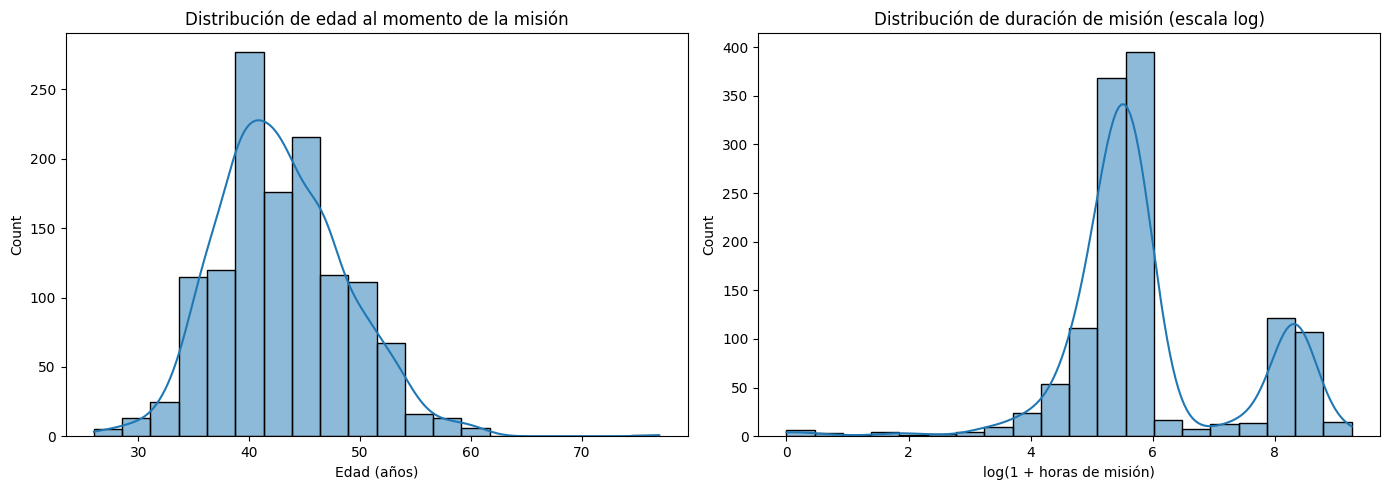

In [15]:
# Visualizamos la distribución de edad y de duración de misión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_astronautas['edad_en_mision'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribución de edad al momento de la misión')
axes[0].set_xlabel('Edad (años)')

# Usamos log porque hours_mission tiene mucha cola larga (ver el describe() anterior)
sns.histplot(np.log1p(df_astronautas['hours_mission']), bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribución de duración de misión (escala log)')
axes[1].set_xlabel('log(1 + horas de misión)')

plt.tight_layout()
plt.show()

In [16]:
# Identificamos quién es el astronauta de mayor edad y en qué misión
df_astronautas[df_astronautas['edad_en_mision'] == df_astronautas['edad_en_mision'].max()][['name', 'year_of_mission', 'mission_title', 'occupation']]

,name,year_of_mission,mission_title,occupation
3,"Glenn, John H., Jr.",1998,STS-95,PSP


In [17]:
# Verificamos si las dos "campanas" corresponden a distintos tipos de módulo/nave (in_orbit)
df_astronautas.groupby('in_orbit')['hours_mission'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

,count,mean,median
in_orbit,,,
ISS,174,4162.129655,4037.00
Mir,71,3962.129155,4201.00
Mir/Salyut 7,2,3000.000000,3000.00
Salyut 7,24,2136.575000,920.00
Skylab 4,3,2017.000000,2017.00
...,...,...,...
Mercury-Atlas 7,1,5.000000,5.00
MA-6,1,5.000000,5.00
Gemini 3,2,4.860000,4.86


In [20]:
# Creamos una categoría simplificada a partir de in_orbit, agrupando por tipo de misión
# Esto convierte 289 categorías dispersas en un grupo manejable, basado en lo que ya observamos

estaciones = ['ISS', 'Mir', 'Salyut 6', 'Salyut 7', 'Skylab 2', 'Skylab 3', 'Skylab 4', 'Mir/Salyut 7']

def clasificar_tipo_mision(valor):
    if valor in estaciones:
        return 'Estación espacial'
    elif valor in ['explosion', 'aborted']:
        return 'Misión fallida'
    else:
        return 'Vuelo orbital corto'

df_astronautas['tipo_mision'] = df_astronautas['in_orbit'].apply(clasificar_tipo_mision)

# Verificamos que la nueva categoría explique la bimodalidad
df_astronautas.groupby('tipo_mision')['hours_mission'].agg(['count', 'mean', 'median'])

,count,mean,median
tipo_mision,,,
Estación espacial,301,3678.968306,3990.42
Misión fallida,9,0.203333,0.00
Vuelo orbital corto,967,242.613814,236.18


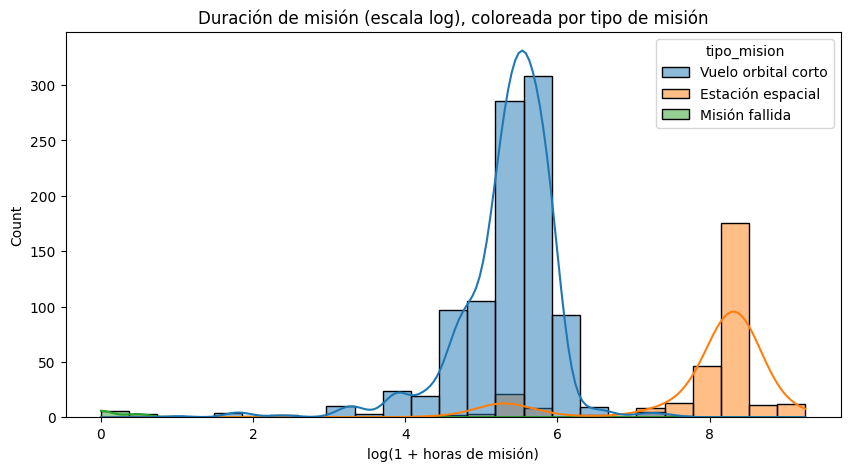

In [19]:
# Volvemos a graficar la distribución, ahora coloreada por tipo de misión
plt.figure(figsize=(10, 5))
sns.histplot(data=df_astronautas, x=np.log1p(df_astronautas['hours_mission']), hue='tipo_mision', bins=25, kde=True)
plt.title('Duración de misión (escala log), coloreada por tipo de misión')
plt.xlabel('log(1 + horas de misión)')
plt.show()

In [21]:
# Fase 3 — Relaciones entre variables
# ¿Cambió la participación femenina a lo largo de las décadas?

# Creamos una columna de década a partir del año de la misión
df_astronautas['decada'] = (df_astronautas['year_of_mission'] // 10) * 10

# Calculamos el porcentaje de mujeres por década
participacion_femenina = df_astronautas.groupby('decada')['sex'].apply(lambda x: (x == 'female').mean() * 100)
print(participacion_femenina)

decada
1960     1.515152
1970     0.000000
1980     7.359307
1990    15.044248
2000    12.671233
2010    12.738854
Name: sex, dtype: float64


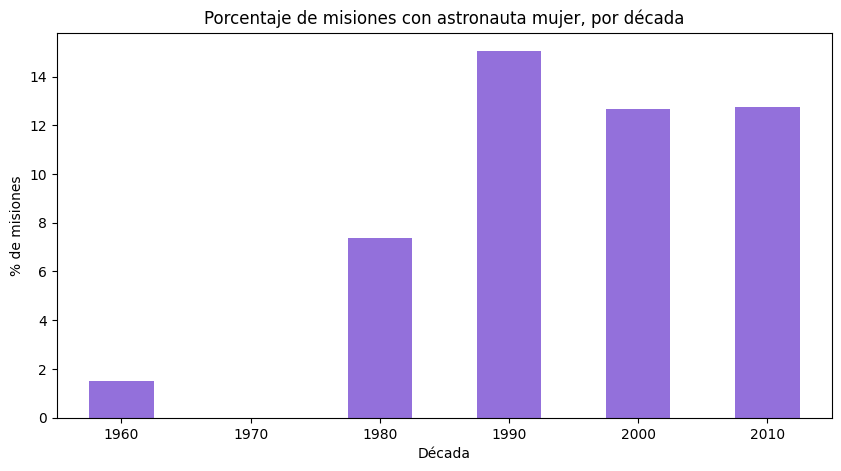

In [22]:
# Visualizamos la tendencia
plt.figure(figsize=(10, 5))
participacion_femenina.plot(kind='bar', color='mediumpurple')
plt.title('Porcentaje de misiones con astronauta mujer, por década')
plt.ylabel('% de misiones')
plt.xlabel('Década')
plt.xticks(rotation=0)
plt.show()

In [23]:
# Cruzamos tipo de misión con perfil militar/civil
tabla_cruzada = pd.crosstab(df_astronautas['tipo_mision'], df_astronautas['military_civilian'], normalize='index') * 100
print(tabla_cruzada.round(1))

military_civilian    civilian  military
tipo_mision                            
Estación espacial        36.5      63.5
Misión fallida           44.4      55.6
Vuelo orbital corto      40.7      59.3


In [24]:
from scipy.stats import chi2_contingency

# Test de chi-cuadrado: ¿el tipo de misión y el perfil militar/civil son independientes?
tabla_contingencia = pd.crosstab(df_astronautas['tipo_mision'], df_astronautas['military_civilian'])
chi2, p_valor, gl, esperado = chi2_contingency(tabla_contingencia)

print(f"Estadístico chi-cuadrado: {chi2:.2f}")
print(f"p-valor: {p_valor:.4f}")
print(f"Grados de libertad: {gl}")

if p_valor < 0.05:
    print("\n→ Hay asociación estadísticamente significativa (p < 0.05)")
else:
    print("\n→ No hay evidencia suficiente de asociación (p ≥ 0.05): la diferencia observada es compatible con el azar")

Estadístico chi-cuadrado: 1.77
p-valor: 0.4122
Grados de libertad: 2

→ No hay evidencia suficiente de asociación (p ≥ 0.05): la diferencia observada es compatible con el azar


Correlación entre año de misión y edad: 0.420


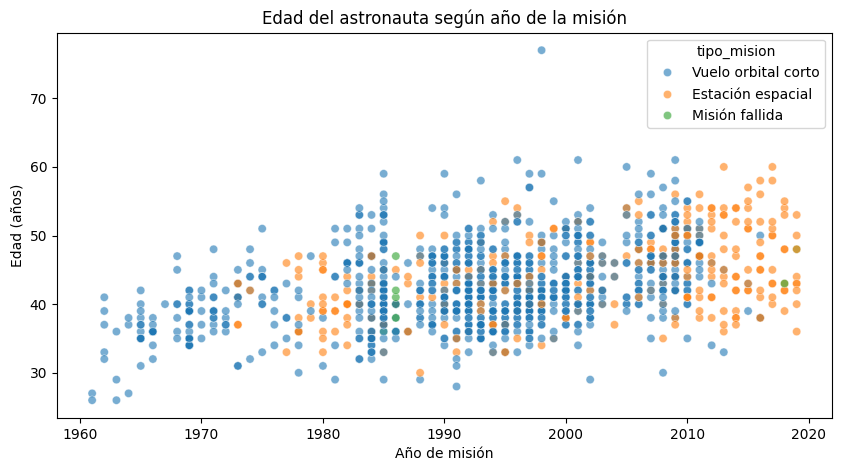

In [25]:
# Relación entre año de misión y edad del astronauta
correlacion_edad_anio = df_astronautas[['year_of_mission', 'edad_en_mision']].corr().iloc[0, 1]
print(f"Correlación entre año de misión y edad: {correlacion_edad_anio:.3f}")

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_astronautas, x='year_of_mission', y='edad_en_mision', hue='tipo_mision', alpha=0.6)
plt.title('Edad del astronauta según año de la misión')
plt.xlabel('Año de misión')
plt.ylabel('Edad (años)')
plt.show()

In [26]:
# Última relación: ¿la nacionalidad (top 3) tiene distinta proporción de mujeres?
top3_paises = ['U.S.', 'U.S.S.R/Russia']  # el resto tiene muestras muy chicas para comparar con confianza

df_top3 = df_astronautas[df_astronautas['nationality'].isin(top3_paises)]
print(df_top3.groupby('nationality')['sex'].apply(lambda x: (x == 'female').mean() * 100).round(1))

nationality
U.S.              14.6
U.S.S.R/Russia     2.2
Name: sex, dtype: float64


In [27]:
# Y la duración promedio de misión por país (top 3), para ver si alguno tiende a estadías más largas
print(df_top3.groupby('nationality')['hours_mission'].agg(['mean', 'median']).round(1))

                  mean  median
nationality                   
U.S.             592.2   243.0
U.S.S.R/Russia  2513.0  3000.0


**Conclusiones del EDA:**
- El dataset está excepcionalmente limpio: 0 duplicados, nulos mínimos y completamente explicables (turistas espaciales sin programa de selección formal).
- `field21` corresponde, con alta probabilidad, a la cantidad de caminatas espaciales (EVAs) por misión (correlación de 0.9456 con `eva_hrs_mission`).
- La duración de misión (`hours_mission`) tiene una distribución bimodal explicada casi por completo por el tipo de misión: vuelo orbital corto (mediana 236 hs) vs. estadía en estación espacial (mediana 3990 hs).
- La participación femenina no creció linealmente: pasó de 0% en los 70s a un pico de 15% en los 90s, estabilizándose en ~12.7% desde entonces — y varía fuertemente por país (14.6% en EE.UU. vs. 2.2% en Rusia/URSS).
- El perfil militar/civil **no** varía significativamente según el tipo de misión (chi-cuadrado, p=0.41): la hipótesis de que las estaciones espaciales tendrían más civiles no se sostiene con evidencia.
- Existe una correlación moderada (0.42) entre año de misión y edad del astronauta, coherente con la incorporación progresiva de perfiles científicos/médicos de carrera más avanzada.
- El caso de John Glenn (77 años, STS-95, 1998) es un outlier real y documentado, no un error de carga.

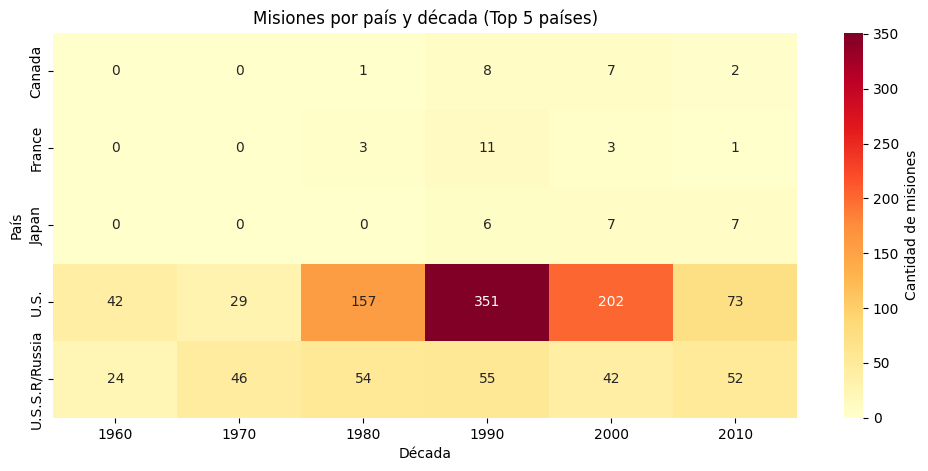

In [29]:
# Visualización 1 — Heatmap de misiones por año y país (top 5 países)

top5_paises = df_astronautas['nationality'].value_counts().head(5).index

# Pivot: filas = país, columnas = década, valores = cantidad de misiones
pivot_paises = df_astronautas[df_astronautas['nationality'].isin(top5_paises)].pivot_table(
    index='nationality',
    columns='decada',
    values='id',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_paises, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Cantidad de misiones'})
plt.title('Misiones por país y década (Top 5 países)')
plt.xlabel('Década')
plt.ylabel('País')
plt.show()

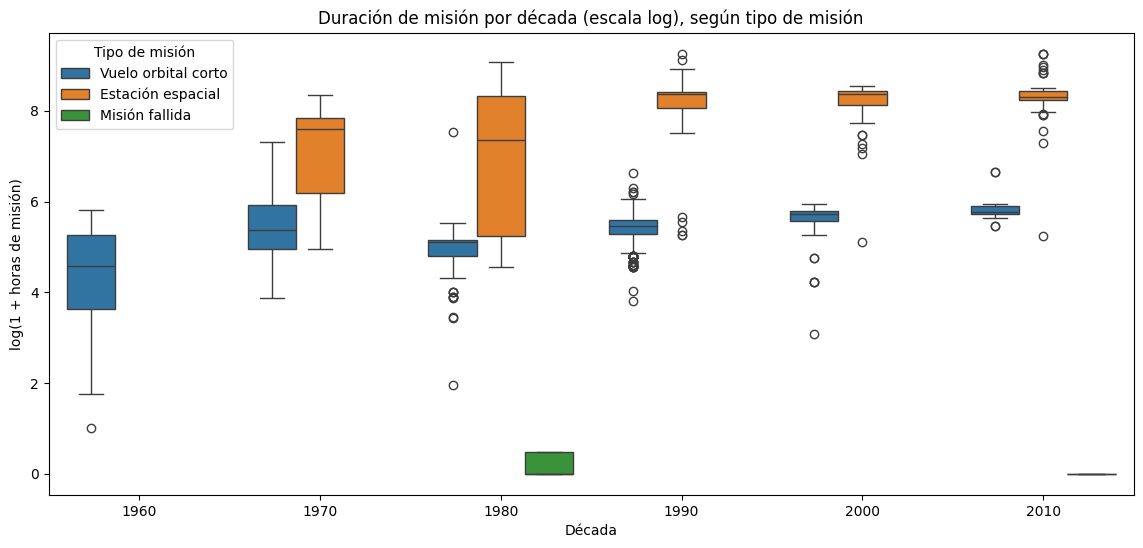

In [30]:
# Visualización 2 — Boxplot de duración de misión por década, separado por tipo de misión

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_astronautas,
    x='decada',
    y=np.log1p(df_astronautas['hours_mission']),
    hue='tipo_mision'
)
plt.title('Duración de misión por década (escala log), según tipo de misión')
plt.xlabel('Década')
plt.ylabel('log(1 + horas de misión)')
plt.legend(title='Tipo de misión')
plt.show()

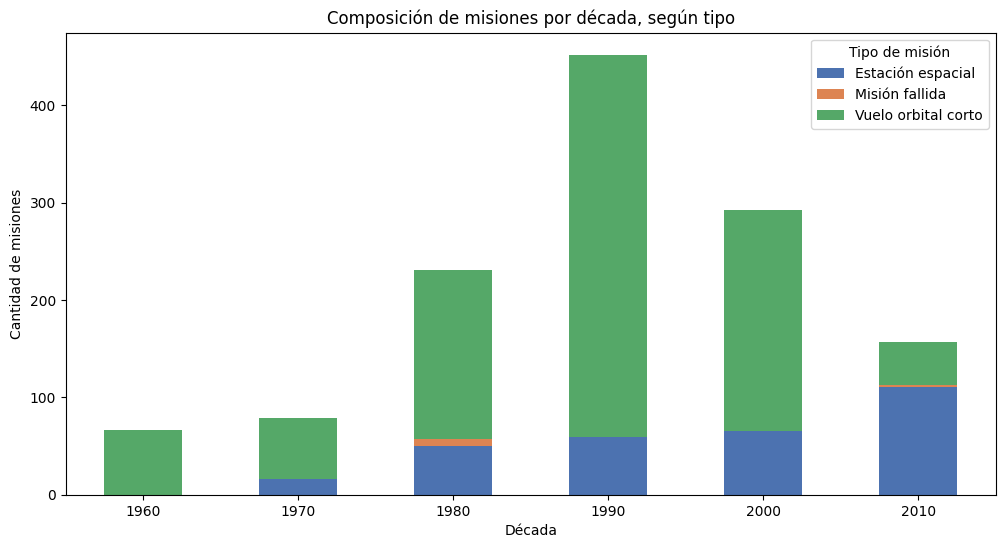

In [31]:
# Visualización 3 — Barras apiladas de tipo de misión por década

conteo_tipo_decada = pd.crosstab(df_astronautas['decada'], df_astronautas['tipo_mision'])

conteo_tipo_decada.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#4C72B0', '#DD8452', '#55A868']  # mismos colores que el boxplot, para consistencia visual
)
plt.title('Composición de misiones por década, según tipo')
plt.xlabel('Década')
plt.ylabel('Cantidad de misiones')
plt.xticks(rotation=0)
plt.legend(title='Tipo de misión')
plt.show()

## Conclusiones finales del EDA

**Calidad de los datos:**
- Dataset excepcionalmente limpio: 0 duplicados, nulos mínimos y completamente explicables (turistas espaciales sin programa de selección formal).
- `field21` corresponde, con alta probabilidad, a la cantidad de caminatas espaciales (EVAs) por misión — inferido por correlación (0.9456) con `eva_hrs_mission`, ya que el dataset original no documenta esta columna.

**Duración de misión:**
- Distribución bimodal explicada por el tipo de misión: vuelo orbital corto (mediana 236 hs) vs. estación espacial (mediana 3990 hs).
- Ambas categorías se alargaron con el tiempo: los vuelos cortos pasaron de horas a semanas; las estadías en estación se estandarizaron a partir de 1990 tras una fase experimental muy variable en los 70s-80s.
- El fin del programa de transbordadores (2011) se refleja claramente en los datos: la década de 2010 es la primera donde las misiones de estación superan a los vuelos cortos, y el volumen total de misiones cae.

**Participación femenina:**
- No creció linealmente: 0% en los 70s, pico de 15% en los 90s, meseta de ~12.7% desde entonces.
- Varía fuertemente por país: 14.6% en EE.UU. vs. 2.2% en Rusia/URSS.

**Perfil militar/civil:**
- No varía significativamente según el tipo de misión (chi-cuadrado, p=0.41) — la hipótesis de que las estaciones espaciales tendrían más perfiles civiles no se sostiene con evidencia estadística.

**Edad:**
- Correlación moderada (0.42) entre año de misión y edad del astronauta, coherente con la incorporación progresiva de perfiles científicos/médicos de carrera más avanzada.
- Caso atípico documentado: John Glenn, 77 años, STS-95 (1998) — parte de un estudio real de la NASA sobre envejecimiento en el espacio, no un error de datos.

**Dominancia por país:**
- EE.UU. y Rusia/URSS concentran el 88% de todas las misiones registradas.
- El resto de los países (Japón, Francia, Canadá, etc.) recién se incorporan a partir de los años 80, como socios internacionales.